In [1]:
import pandas as pd

### Load in the parquet files

In [2]:
# load in parquet files
X_train_scaled = pd.read_parquet("data/X_train_scaled.parquet")
X_test_scaled = pd.read_parquet("data/X_test_scaled.parquet")
y_train = pd.read_parquet("data/y_train.parquet")
y_test = pd.read_parquet("data/y_test.parquet")

In [3]:
#split train and data into train and validation
from sklearn.model_selection import train_test_split
X_train_scaled, X_val_scaled, y_train, y_val = train_test_split(X_train_scaled, y_train, test_size=0.15, random_state=42)

### Build NAM archictecture

In [4]:
# NAM architecture
import torch
import torch.nn as nn
import torch.optim as optim

class SingleFeatureNN(nn.Module):
    def __init__(self, hidden_sizes=[64, 32], dropout_rate=0.2):
        super().__init__()
        layers, input_size = [], 1
        for h in hidden_sizes:
            layers += [nn.Linear(input_size, h), nn.ReLU(), nn.Dropout(dropout_rate)]
            input_size = h
        layers.append(nn.Linear(input_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class NAM(nn.Module):
    def __init__(self, num_features, hidden_sizes=[64, 32], dropout_rate=0.1):
        super().__init__()
        self.feature_nns = nn.ModuleList([
            SingleFeatureNN(hidden_sizes, dropout_rate) for _ in range(num_features)
        ])
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        outs = [self.feature_nns[i](x[:, i].unsqueeze(1)) for i in range(x.shape[1])]
        return torch.cat(outs, dim=1).sum(dim=1) + self.bias

In [5]:
# hyperparameter tuning (pick best by validation AUROC)
from sklearn.metrics import roc_auc_score

torch.manual_seed(42)

X_train_tensor = torch.tensor(X_train_scaled.to_numpy(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy().ravel(), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled.to_numpy(), dtype=torch.float32)
y_val_np = y_val.to_numpy().ravel()

num_features = X_train_tensor.shape[1]
epochs = 200
criterion = nn.BCEWithLogitsLoss()

grid = [
    ([64, 32], 0.0, 1e-3, 0.0),
    ([64, 32], 0.1, 5e-4, 1e-5),
    ([128, 64], 0.05, 5e-4, 1e-5),
    ([128, 64, 32], 0.05, 5e-4, 1e-5),
    ([128, 64, 32], 0.1, 2e-4, 1e-5),
]

best_val_auroc, best_params, best_model = -1.0, None, None
for hidden_sizes, dropout_rate, lr, weight_decay in grid:
    model = NAM(num_features, hidden_sizes=hidden_sizes, dropout_rate=dropout_rate)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_tensor), y_train_tensor)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        val_prob = torch.sigmoid(model(X_val_tensor)).cpu().numpy()
    val_auroc = roc_auc_score(y_val_np, val_prob)
    params = {"hidden_sizes": hidden_sizes, "dropout": dropout_rate, "lr": lr, "wd": weight_decay}
    print(params, "val_auroc", round(val_auroc, 4))
    
    if val_auroc > best_val_auroc:
        best_val_auroc, best_params, best_model = val_auroc, params, model

model = best_model
print("best:", best_params, "val_auroc", round(best_val_auroc, 4))

{'hidden_sizes': [64, 32], 'dropout': 0.0, 'lr': 0.001, 'wd': 0.0} val_auroc 0.9348
{'hidden_sizes': [64, 32], 'dropout': 0.1, 'lr': 0.0005, 'wd': 1e-05} val_auroc 0.9375
{'hidden_sizes': [128, 64], 'dropout': 0.05, 'lr': 0.0005, 'wd': 1e-05} val_auroc 0.9348
{'hidden_sizes': [128, 64, 32], 'dropout': 0.05, 'lr': 0.0005, 'wd': 1e-05} val_auroc 0.932
{'hidden_sizes': [128, 64, 32], 'dropout': 0.1, 'lr': 0.0002, 'wd': 1e-05} val_auroc 0.9348
best: {'hidden_sizes': [64, 32], 'dropout': 0.1, 'lr': 0.0005, 'wd': 1e-05} val_auroc 0.9375


### Test performance

In [20]:
# check the performance on the test set
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, balanced_accuracy_score

X_test_tensor = torch.tensor(X_test_scaled.to_numpy(), dtype=torch.float32)
y_test_np = y_test.to_numpy().ravel()

model.eval()
with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits).cpu().numpy()

binary_predictions = (probabilities >= 0.5).astype(int)

print("best params:", best_params)
print(f"Val AUROC: {best_val_auroc:.3f}")
print(f"Test AUROC: {roc_auc_score(y_test_np, probabilities):.3f}")
print(f"Precision: {precision_score(y_test_np, binary_predictions):.3f}")
print(f"Recall: {recall_score(y_test_np, binary_predictions):.3f}")
print(f"F1-score: {f1_score(y_test_np, binary_predictions):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_np, binary_predictions):.3f}")
print(f"test accuracy: {(binary_predictions == y_test_np).mean():.3f}")

best params: {'hidden_sizes': [64, 32], 'dropout': 0.1, 'lr': 0.0005, 'wd': 1e-05}
Val AUROC: 0.938
Test AUROC: 0.931
Precision: 0.917
Recall: 0.863
F1-score: 0.889
Balanced Accuracy: 0.883
test accuracy: 0.880


### Feature Importance

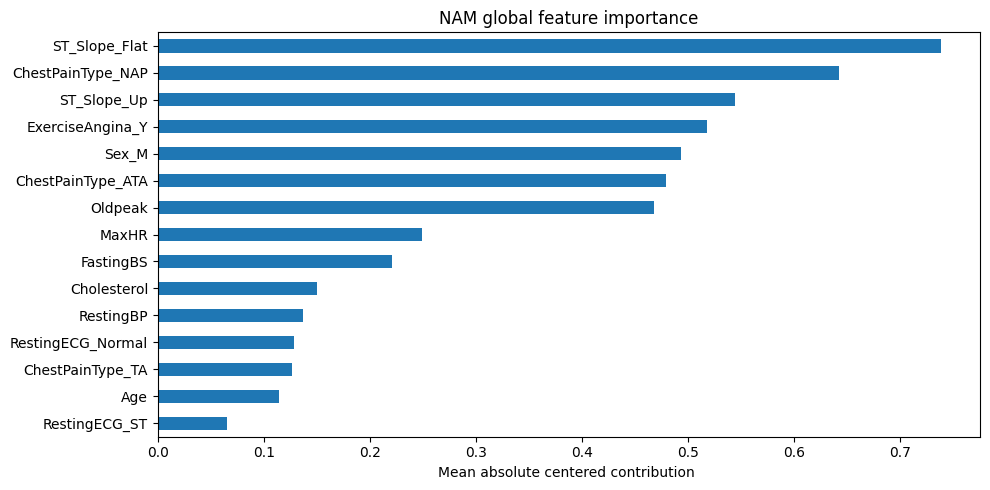

In [22]:
# feature importance
import matplotlib.pyplot as plt
import numpy as np

def nam_contrib_df(model, X_df: pd.DataFrame) -> pd.DataFrame:
    """Per-row, per-feature contributions f_i(x_i) in logit units."""
    model.eval()
    device = next(model.parameters()).device
    X = torch.tensor(X_df.to_numpy(), dtype=torch.float32, device=device)

    with torch.no_grad():
        contrib = torch.cat(
            [fnn(X[:, i:i+1]) for i, fnn in enumerate(model.feature_nns)],
            dim=1
        )  # (N, d)

    return pd.DataFrame(contrib.cpu().numpy(), columns=X_df.columns, index=X_df.index)

# We analyze the results on the test data
contrib = nam_contrib_df(model, X_test_scaled)
contrib_train = nam_contrib_df(model, X_train_scaled)
# Center per feature to remove arbitrary constant offsets
contrib_centered = contrib - contrib_train.mean(axis=0)

# Global importance: "typical magnitude" of the feature’s contribution
importance = contrib_centered.abs().mean(axis=0).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance.iloc[::-1].plot(kind="barh")
plt.xlabel("Mean absolute centered contribution ")
plt.title(f"NAM global feature importance")
plt.tight_layout()
plt.show()